In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_df = pd.read_csv('/content/Users.csv', on_bad_lines='skip')
display(users_df.head())

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [3]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [4]:
users_df.isnull().sum()

,0
User-ID,0
Location,0
Age,110762


In [5]:
users_df.duplicated().sum()

np.int64(0)

In [6]:
ratings_df = pd.read_csv('/content/Ratings.csv')
display(ratings_df.head())

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [7]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [8]:
ratings_df.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


In [9]:
ratings_df.duplicated().sum()

np.int64(0)

In [10]:
books_df = pd.read_csv('/content/Books.csv')
display(books_df.head())

/tmp/ipython-input-1182426602.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv('/content/Books.csv')


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [11]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252512 entries, 0 to 252511
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 252512 non-null  object
 1   Book-Title           252512 non-null  object
 2   Book-Author          252510 non-null  object
 3   Year-Of-Publication  252512 non-null  object
 4   Publisher            252510 non-null  object
 5   Image-URL-S          252512 non-null  object
 6   Image-URL-M          252512 non-null  object
 7   Image-URL-L          252509 non-null  object
dtypes: object(8)
memory usage: 15.4+ MB


In [12]:
books_df.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


In [13]:
books_df.duplicated().sum()

np.int64(0)

EDA

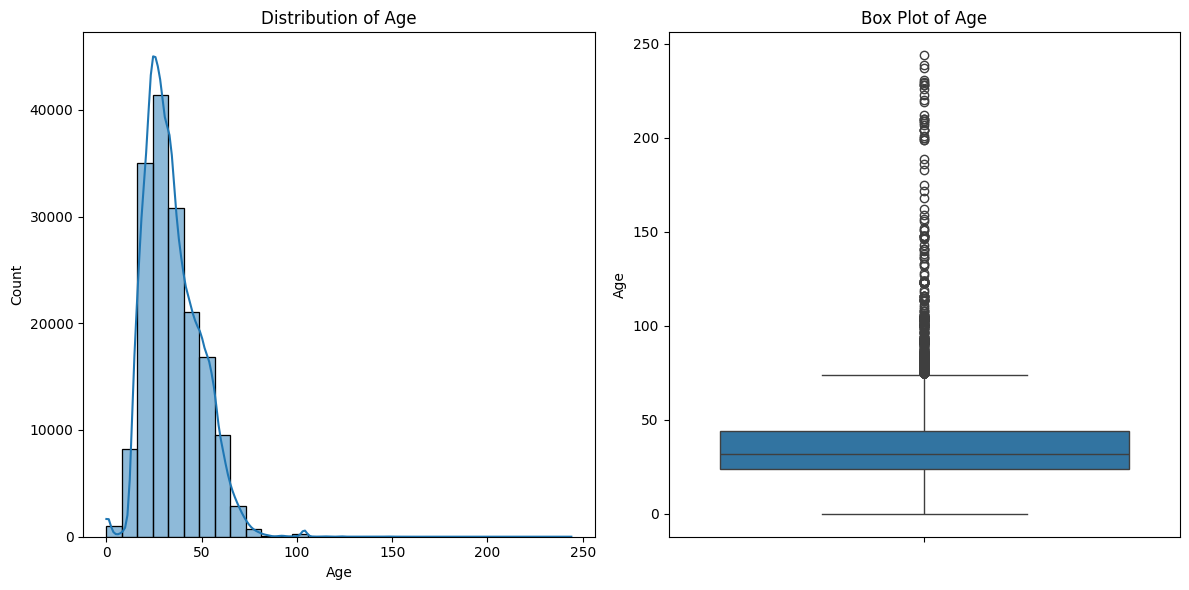

In [14]:
# Visualize the distribution of 'Age'
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(users_df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=users_df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

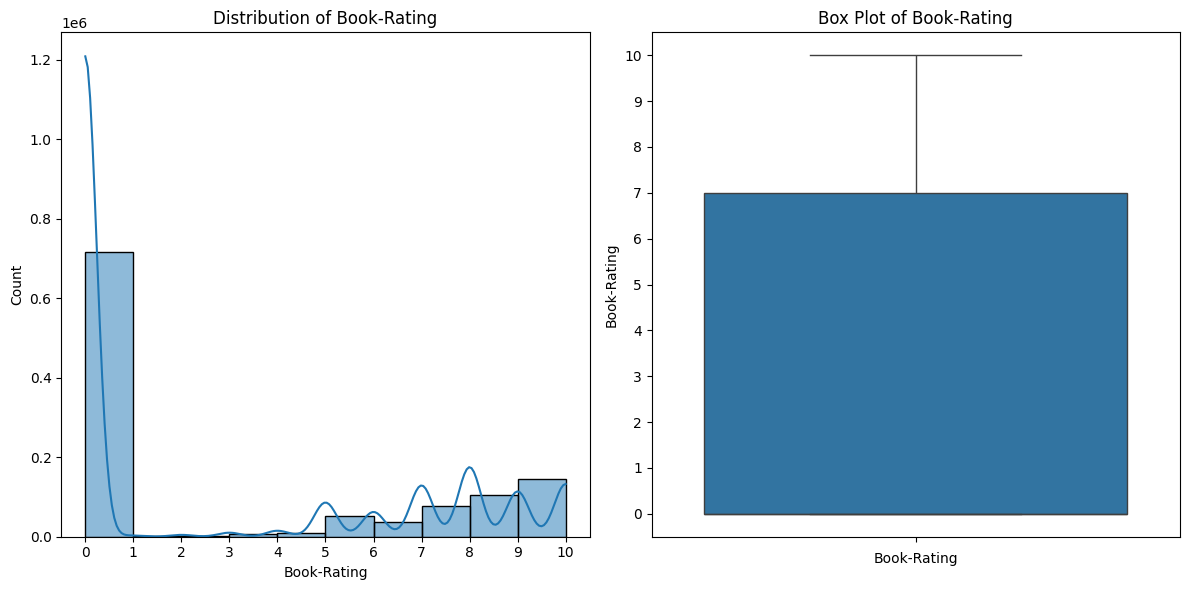

In [15]:
# Visualize the distribution of 'Book-Rating'
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(ratings_df['Book-Rating'], bins=10, kde=True)
plt.title('Distribution of Book-Rating')
plt.xlabel('Book-Rating')
plt.ylabel('Count')
plt.xticks(range(0, 11)) # Assuming ratings are from 0-10

plt.subplot(1, 2, 2)
sns.boxplot(y=ratings_df['Book-Rating'])
plt.title('Box Plot of Book-Rating')
plt.xlabel('Book-Rating')
plt.yticks(range(0, 11)) # Assuming ratings are from 0-10

plt.tight_layout()
plt.show()

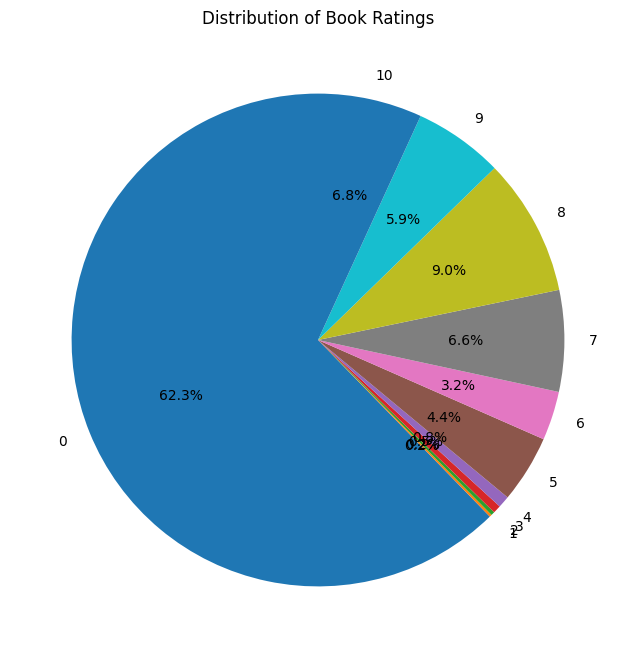

In [16]:
# Calculate the frequency of each book rating
rating_counts = ratings_df['Book-Rating'].value_counts().sort_index()

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Book Ratings')
plt.ylabel('') # Hide y-label as it's not relevant for pie chart
plt.show()

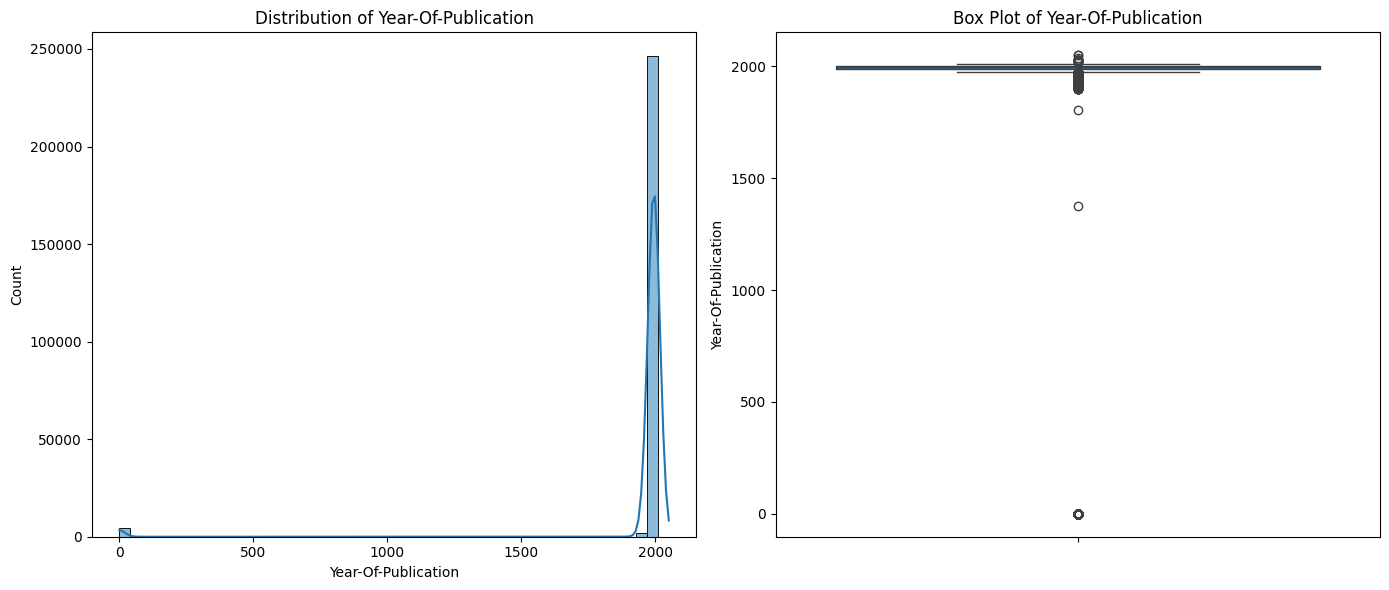

In [17]:
# Visualize the distribution of 'Year-Of-Publication'

# Convert 'Year-Of-Publication' to numeric, coercing errors to NaN
books_df['Year-Of-Publication'] = pd.to_numeric(books_df['Year-Of-Publication'], errors='coerce')

# Fill any remaining NaN values with the median year (calculated after coercion)
median_year = books_df['Year-Of-Publication'].median()
books_df['Year-Of-Publication'] = books_df['Year-Of-Publication'].fillna(median_year)

# Convert to nullable integer type
books_df['Year-Of-Publication'] = books_df['Year-Of-Publication'].astype('Int64')

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(books_df['Year-Of-Publication'], bins=50, kde=True)
plt.title('Distribution of Year-Of-Publication')
plt.xlabel('Year-Of-Publication')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=books_df['Year-Of-Publication'])
plt.title('Box Plot of Year-Of-Publication')
plt.ylabel('Year-Of-Publication')

plt.tight_layout()
plt.show()

In [18]:
# Identify and count unusual year values (e.g., year 0 or future years)
unusual_years = books_df[(books_df['Year-Of-Publication'] < 1000) | (books_df['Year-Of-Publication'] > 2024)]
print(f"Number of unusual publication years: {len(unusual_years)}")
print("Unusual publication years and their counts:")
display(unusual_years['Year-Of-Publication'].value_counts().sort_index())

Number of unusual publication years: 4350
Unusual publication years and their counts:


,count
Year-Of-Publication,
0,4340
2026,1
2030,6
2038,1
2050,2


popularity based recommendation system

In [19]:
merged_df = pd.merge(ratings_df, books_df, on='ISBN')
display(merged_df.head())

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [20]:
num_ratings = merged_df.groupby('Book-Title')['Book-Rating'].count().reset_index()
num_ratings.rename(columns={'Book-Rating': 'Num-Ratings'}, inplace=True)
display(num_ratings.head())

,Book-Title,Num-Ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Apple Magic (The Collector's series),1
2,Beyond IBM: Leadership Marketing and Finance ...,1
3,Clifford Visita El Hospital (Clifford El Gran...,1
4,Dark Justice,1


In [21]:
avg_ratings = merged_df.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_ratings.rename(columns={'Book-Rating': 'Avg-Ratings'}, inplace=True)
display(avg_ratings.head())

,Book-Title,Avg-Ratings
0,A Light in the Storm: The Civil War Diary of ...,2.25
1,Apple Magic (The Collector's series),0.00
2,Beyond IBM: Leadership Marketing and Finance ...,0.00
3,Clifford Visita El Hospital (Clifford El Gran...,0.00
4,Dark Justice,10.00


In [22]:
popular_df = pd.merge(num_ratings, avg_ratings, on='Book-Title')
display(popular_df.head())

,Book-Title,Num-Ratings,Avg-Ratings
0,A Light in the Storm: The Civil War Diary of ...,4,2.25
1,Apple Magic (The Collector's series),1,0.00
2,Beyond IBM: Leadership Marketing and Finance ...,1,0.00
3,Clifford Visita El Hospital (Clifford El Gran...,1,0.00
4,Dark Justice,1,10.00


In [23]:
popular_df = popular_df[popular_df['Num-Ratings'] >= 250].sort_values('Avg-Ratings', ascending=False).head(50)
display(popular_df.head())

,Book-Title,Num-Ratings,Avg-Ratings
74904,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
74893,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
74911,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
74896,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
74885,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453


In [24]:
popular_df= popular_df.merge(books_df, on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','Num-Ratings','Avg-Ratings']]

In [25]:
popular_df.shape

(50, 5)

collaborative filtering based recommendation system

In [28]:
x = merged_df.groupby('User-ID').count()['Book-Rating']>200
user_id_200 =x[x].index

In [29]:
filtered_rating = merged_df[merged_df['User-ID'].isin(user_id_200)]

In [30]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books = y[y].index

In [31]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [32]:
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [46]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
pt.duplicated().sum()

np.int64(0)

In [33]:
pt.fillna(0,inplace=True)

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

In [35]:
similarity_scores = cosine_similarity(pt)

In [36]:
similarity_scores.shape

(702, 702)

In [41]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:6]
    for i in similar_items:
        print(pt.index[i[0]])

In [42]:
recommend('Message in a Bottle')

Nights in Rodanthe
The Mulberry Tree
A Walk to Remember
River's End
Nightmares &amp; Dreamscapes


In [43]:
import pickle
pickle.dump(popular_df,open('popular.pkl','wb'))

In [45]:
books_df.drop_duplicates('Book-Title')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
252507,0373070985,Lucifer'S Playground,Diana Dixon,1985,Silhouette,http://images.amazon.com/images/P/0373070985.0...,http://images.amazon.com/images/P/0373070985.0...,http://images.amazon.com/images/P/0373070985.0...
252508,0373071590,"Killing Moon (Silhouette Intimate Moments, No ...",Amanda Stevens,1986,Silhouette,http://images.amazon.com/images/P/0373071590.0...,http://images.amazon.com/images/P/0373071590.0...,http://images.amazon.com/images/P/0373071590.0...
252509,0373071795,"Another Chance (Silhouette Intimate Moments, N...",Marion Smith Collins,1987,Silhouette,http://images.amazon.com/images/P/0373071795.0...,http://images.amazon.com/images/P/0373071795.0...,http://images.amazon.com/images/P/0373071795.0...
252510,0373071841,September Rainbow (Silhouette Intimate Moments...,Sibylle Garrett,1987,Silhouette,http://images.amazon.com/images/P/0373071841.0...,http://images.amazon.com/images/P/0373071841.0...,http://images.amazon.com/images/P/0373071841.0...


In [47]:
pickle.dump(pt,open('pt.pkl','wb'))
pickle.dump(books_df,open('books.pkl','wb'))
pickle.dump(similarity_scores,open('similarity_scores.pkl','wb'))